# In this notebook, we are going to learn three widely used clustering models.

<font color='red'>Question:</font> What are supervised learning and unsupervised learning?

<font color='red'>Question:</font> Why unsupervised learning is important?

# 1. *k*-Means

## 1.1 Modeling

<font color='red'>Assignment:</font> Load the data in '../data/clustering.csv' into a DataFrame **df**, and plot the data in **df**.

In [30]:
import pandas as pd
df = pd.read_csv('clustering.csv')
df.shape

(404, 2)

In [31]:
df.head()

,x1,x2
0,3.101246,6.183914
1,1.083915,12.311124
2,-4.100572,50.639475
3,-3.350454,104.422200
4,-4.256006,52.260368


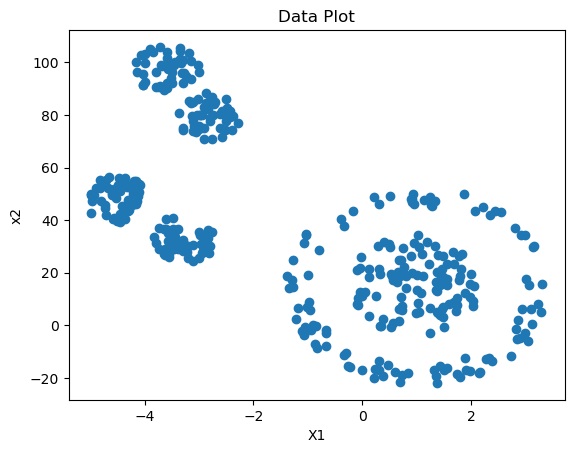

In [32]:
import matplotlib.pyplot as plt

# Scatter plot of the data points
plt.scatter(df['x1'], df['x2'])
plt.xlabel('X1')
plt.ylabel('x2')
plt.title('Data Plot')

# Display the plot
plt.show()

<font color='red'>Question:</font> How many clusters do you think there are?

<font color='red'>Assignment:</font> Train a **KMeans** model with the data in **df**. Set **n_cluster** the number of clusters which you think is reasonable.

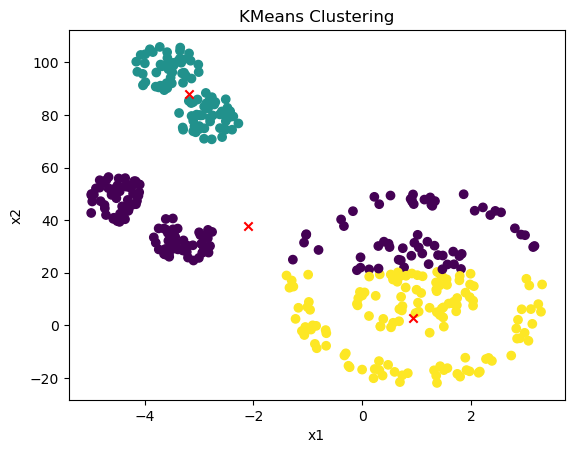

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Extract the features from the DataFrame
X = df[['x1', 'x2']]

# Set the number of clusters
n_clusters = 3
# Create an instance of the KMeans model
kmeans = KMeans(n_clusters=n_clusters)

# Fit the model to the data
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_

# Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_

# Plot the data points with color-coded clusters
plt.scatter(X['x1'], X['x2'], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='x', c='red')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('KMeans Clustering')
plt.show()






<font color='red'>Question:</font> What information does the attribute **label_** of **KMeans** provide?

<font color='red'>Assignment:</font> Visualize the clustering results. **Hint:** use **plt.scatter(x, y, c=z)**.

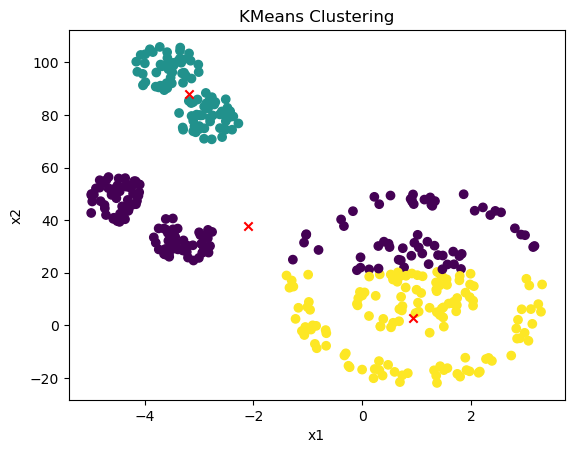

In [35]:
# Plot the data points with color-coded clusters
plt.scatter(X['x1'], X['x2'], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='x', c='red')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('KMeans Clustering')
plt.show()


<font color='red'>Question:</font> Do you think the result is reasonable? What is the reason? How can you solve it? **Hint:** Re-plot the clustering results with **plt.axis('equal')**.

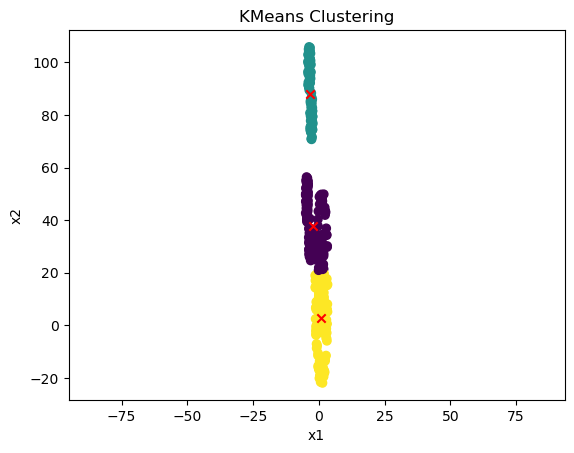

In [36]:
plt.scatter(X['x1'], X['x2'], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='x', c='red')
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('KMeans Clustering')
plt.show()

<font color='red'>Assignment:</font> Rescale the data in **df** and assign them to a variable X. Re-do the above steps with X.

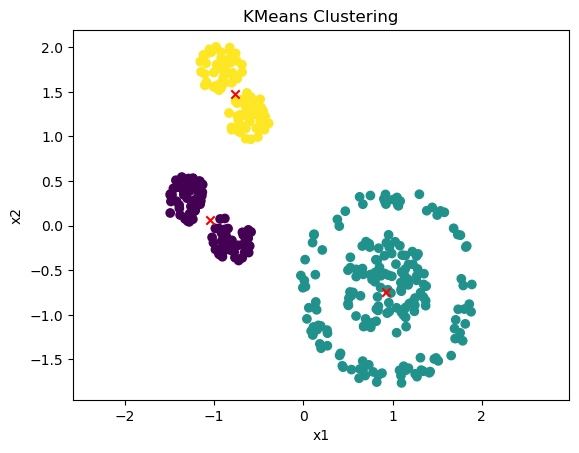

In [37]:
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
scaler = StandardScaler()

# Rescale the data in df
X = scaler.fit_transform(df)

# Train a KMeans model with the rescaled data
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

# Obtain the cluster labels
labels = kmeans.labels_

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', c='red')
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('KMeans Clustering')
plt.show()



#plt.scatter(X[:, 0], X[:, 1], c=labels)
#plt.axis('equal')
#plt.show()






<font color='red'>Question:</font> Do you think it is more reasonable now? Can you describe how **KMeans** works? How **centroids** are initialized and updated? How does the model determine which cluster a data point belongs to?

<font color='red'>Question:</font> What are the important hyperparameters for **KMeans**? How do they affect results?

## 1.2 Elbow Method

<font color='red'>Question:</font> What information does attribute **inertia_** of **KMeans** provide?

<font color='red'>Assignment:</font> Plot **inertia_** value versus **n_clusters**.

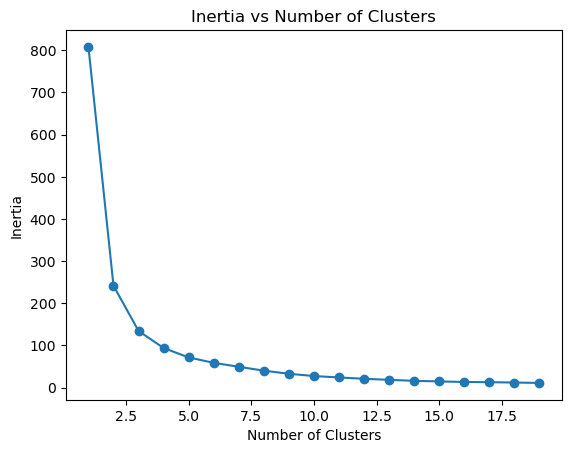

In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Initialize empty lists to store the number of clusters and inertia values
n_clusters_list = []
inertia_values = []

# Vary the number of clusters from 1 to 10
for n_clusters in range(1, 20):
    # Create a KMeans model with the current number of clusters
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(X)
    
    # Append the number of clusters and inertia value to the lists
    n_clusters_list.append(n_clusters)
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values versus the number of clusters
plt.plot(n_clusters_list, inertia_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Inertia vs Number of Clusters')
plt.show()


<font color='red'>Question:</font> How many clusters (or which **k**) should we choose here? Is it consistent with what you found in the figure?

<font color='red'>Question:</font> What is **Elbow Method**? Does it always work?

# 2. Hierarchical Clustering

## 2.1 Modeling

<font color='red'>Assignment:</font> Train an **AgglomerativeClustering** model with **X**.

In [40]:
from sklearn.cluster import AgglomerativeClustering

# Create an instance of the AgglomerativeClustering model
agglomerative = AgglomerativeClustering(n_clusters=3)

# Fit the model to the data
agglomerative.fit(X)

# Obtain the cluster labels
labels = agglomerative.labels_

<font color='red'>Assignment:</font> Visualize the clustering results.

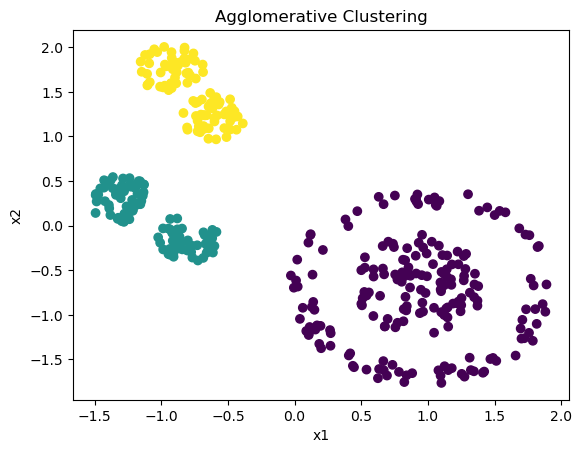

In [41]:
import matplotlib.pyplot as plt

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Agglomerative Clustering')
plt.show()

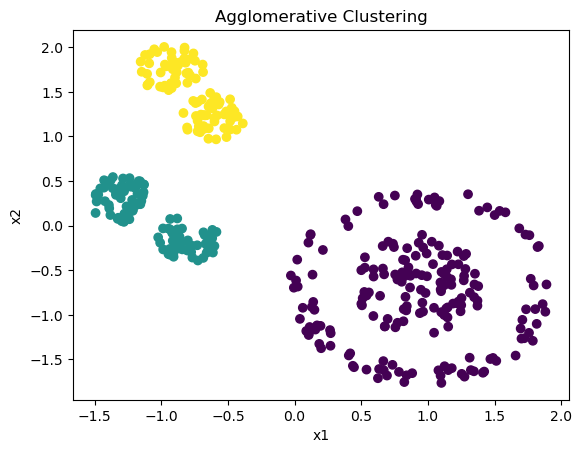

In [51]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Train the AgglomerativeClustering model
agglomerative = AgglomerativeClustering(n_clusters=3)
labels=agglomerative.fit_predict(X)

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Agglomerative Clustering')
plt.show()

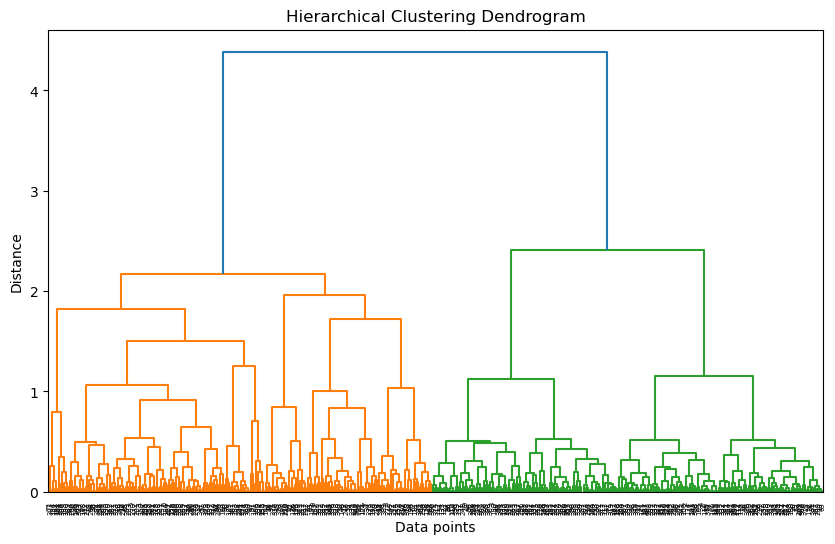

In [44]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram,linkage

# Train the AgglomerativeClustering model
agg_model = AgglomerativeClustering(n_clusters=3)
agg_model.fit(X)

# Obtain the linkage matrix
linkage_matrix = linkage(X, method='complete')  # Use the same method as in AgglomerativeClustering

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.xlabel('Data points')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

<font color='red'>Question:</font> How does hierarchecial clustering work?

<font color='red'>Question:</font> What are the important hyperparameters for **AgglomerativeClustering**? How do they affect results?

## 2.2 Dendrogram

**Example:** Plot dendrogram of hierarchical clustering results. Here we use **linkage** in **scipy** to reproduce the results of **AgglomerativeClustering** model.

Text(0, 0.5, 'distance')

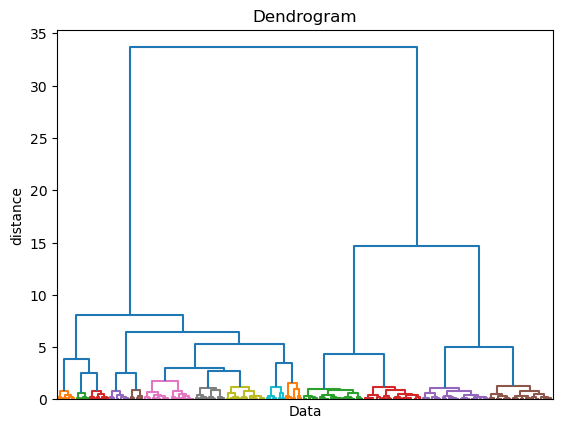

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X, 'ward')
dendrogram(linkage_matrix, color_threshold=2.0)
plt.title('Dendrogram')
plt.xlabel('Data')
plt.xticks([])
plt.ylabel('distance')

# 3. DBSCAN

<font color='red'>Assignment:</font> Train a **DBSCAN** model with **X**.

In [46]:
from sklearn.cluster import DBSCAN

# Create an instance of the DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit the model to the data
dbscan.fit(X)

DBSCAN()

<font color='red'>Assignment:</font> Visualize the clustering results.

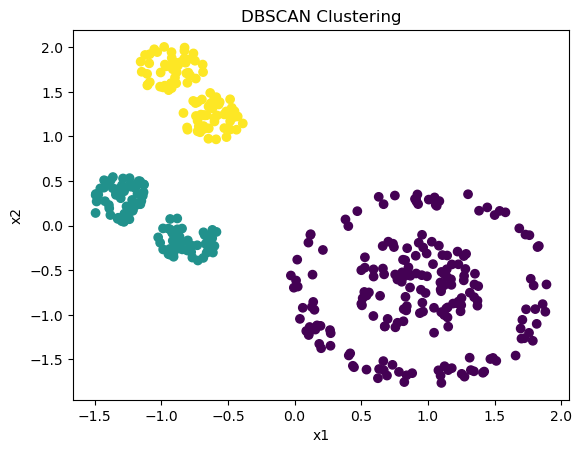

In [47]:
import matplotlib.pyplot as plt

# Get the cluster labels assigned by DBSCAN
labels = dbscan.labels_

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('DBSCAN Clustering')
plt.show()

<font color='red'>Assignment:</font> Tune hyperparameters to make the clustering results more reasonable.

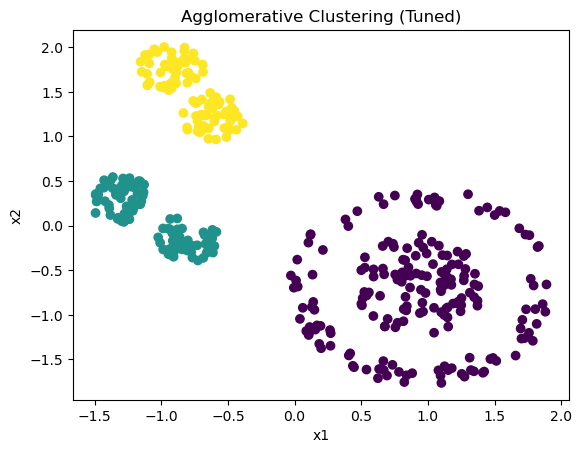

In [57]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Define the parameter grid for manual search
param_grid = {
    'n_clusters': [2, 3, 4, 5],  # Try different values for the number of clusters
    'affinity': ['euclidean', 'cosine', 'manhattan'],  # Try different distance metrics
    'linkage': ['complete', 'average', 'single']  # Try different linkage criteria
}

best_score = -1  # Initialize the best score

# Iterate over the parameter grid
for n_clusters in param_grid['n_clusters']:
    for affinity in param_grid['affinity']:
        for linkage in param_grid['linkage']:
            # Create an instance of the AgglomerativeClustering model with the current hyperparameters
            agglomerative = AgglomerativeClustering(n_clusters=n_clusters, affinity=affinity, linkage=linkage)
            
            # Fit the model to the data and obtain the cluster labels
            labels = agglomerative.fit_predict(X)
            
            # Calculate the Silhouette score to evaluate the quality of the clustering
            score = silhouette_score(X, labels)
            
            # Check if the current score is better than the previous best score
            if score > best_score:
                best_score = score
                best_params = {'n_clusters': n_clusters, 'affinity': affinity, 'linkage': linkage}

# Train the AgglomerativeClustering model with the best hyperparameters
agglomerative_best = AgglomerativeClustering(**best_params)
labels_best = agglomerative_best.fit_predict(X)

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels_best)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Agglomerative Clustering (Tuned)')
plt.show()




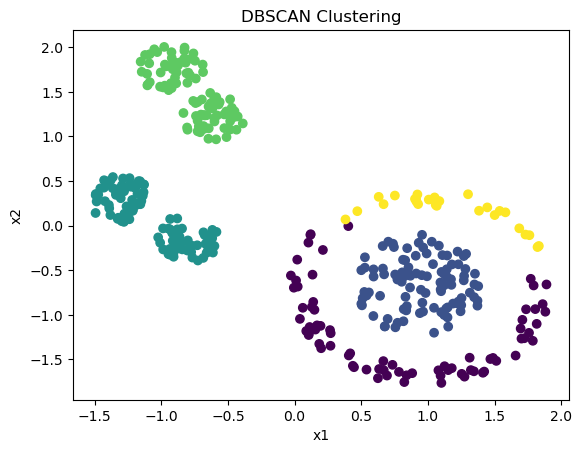

In [56]:
from sklearn.cluster import DBSCAN

# Create an instance of the DBSCAN model
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Fit the DBSCAN model to the data
labels = dbscan.fit_predict(X)

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('DBSCAN Clustering')
plt.show()


<font color='red'>Question:</font> How does **DBSCAN** work?

<font color='red'>Question:</font> What are the important hyperparameters for **DBSCAN**? How do they affect results?

<font color='red'>Question:</font> Do we need to set the number of clusters in **DBSCAN**? Why or why not?